<a href="https://colab.research.google.com/github/madhusudhanreddyd-ux/NASCOM_FDP/blob/main/NASSCOM__day_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd


def build_turbine(csv_path="turbine_energy.csv", seed=152, verbose=False):
    """Wind-turbine daily energy yield — a nonlinear regression with a skewed target,
    correlated features, an outlier-prone signal and a feature that needs transforming.
    Ideal for residual diagnostics, transforms, regularisation and tree ensembles.

    Features:
      wind_speed_ms        average wind speed (m/s)
      wind_std_ms          gustiness (std of wind speed)
      air_density_kgm3     air density (kg/m^3)
      turbulence_intensity fraction (0-1)
      blade_pitch_deg      blade pitch angle (deg)
      rotor_rpm            rotor speed (rpm)
      ambient_temp_c       ambient temperature (deg C)
      turbine_age_years    age of the turbine (years)
    Target:
      energy_kwh           daily energy produced (kWh) — right-skewed
    """
    rng = np.random.default_rng(seed)
    N = 1600
    wind = np.clip(rng.weibull(2.0, N) * 7.0, 0.5, 26)          # Weibull -> right-skew
    wind_std = np.clip(0.12 * wind + rng.normal(0, 0.3, N), 0.05, None)
    density = np.clip(rng.normal(1.225, 0.04, N), 1.10, 1.35)
    turb = np.clip(rng.normal(0.14, 0.05, N), 0.02, 0.40)
    pitch = np.clip(rng.normal(4, 6, N), -2, 25)
    rpm = np.clip(8 + 0.9 * wind + rng.normal(0, 1.5, N), 4, 30)  # correlated with wind
    temp = rng.normal(15, 9, N).round(1)
    age = rng.uniform(0, 20, N)

    # power ~ density * v^3 up to rated, then flattens; losses from pitch, turbulence, age
    cube = np.minimum(wind, 13) ** 3                              # cubic then saturates near rated
    rated_extra = np.maximum(wind - 13, 0) * 120
    energy = (density * (3.1 * cube + rated_extra)
              - 35 * np.abs(pitch - 2)
              - 1800 * turb
              - 22 * age
              + rng.normal(0, 280, N))
    energy = np.clip(energy, 0, None)
    # a few sensor-glitch outliers
    g = rng.choice(N, 18, replace=False)
    energy[g] = energy[g] * rng.uniform(1.6, 2.4, len(g))

    df = pd.DataFrame({
        "wind_speed_ms": wind.round(2), "wind_std_ms": wind_std.round(2),
        "air_density_kgm3": density.round(3), "turbulence_intensity": turb.round(3),
        "blade_pitch_deg": pitch.round(1), "rotor_rpm": rpm.round(1),
        "ambient_temp_c": temp, "turbine_age_years": age.round(1),
        "energy_kwh": energy.round(1),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from scipy.stats import skew
        print("turbine:", df.shape)
        print("energy range:", df.energy_kwh.min(), "-", df.energy_kwh.max())
        print("target skew:", round(skew(df.energy_kwh), 2))
        print("corr(wind, energy):", round(df.wind_speed_ms.corr(df.energy_kwh), 3))
        print("corr(wind, rpm):", round(df.wind_speed_ms.corr(df.rotor_rpm), 3))
    return df

if not os.path.exists('turbine_energy.csv'):
    build_turbine(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('turbine_energy.csv')
TARGET = 'energy_kwh'
features = [c for c in df.columns if c != TARGET]
X = df[features].values; y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('shape:', df.shape, '| features:', len(features))
df.head(3)

shape: (1600, 9) | features: 8


,wind_speed_ms,wind_std_ms,air_density_kgm3,turbulence_intensity,blade_pitch_deg,rotor_rpm,ambient_temp_c,turbine_age_years,energy_kwh
0,4.95,0.81,1.238,0.185,-1.2,13.1,2.4,2.7,0.0
1,6.83,0.84,1.265,0.169,-2.0,15.3,12.1,5.9,527.2
2,1.44,0.05,1.225,0.114,-2.0,7.3,26.1,1.2,0.0


baseline RMSE: 1032.5 kWh | R2: 0.727


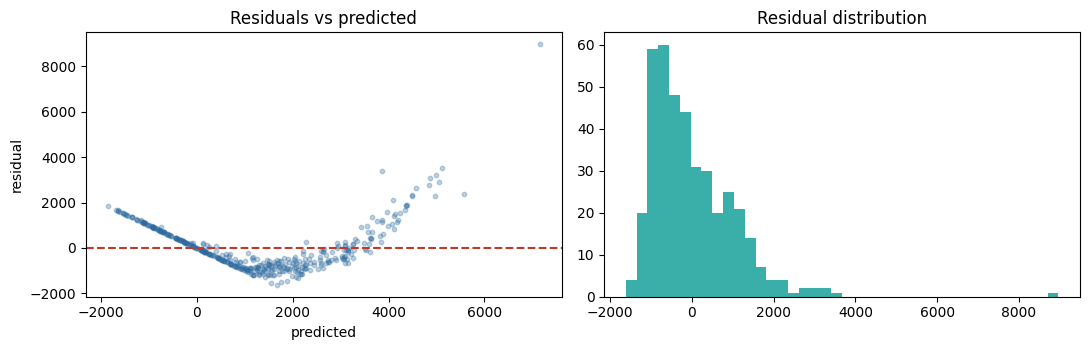

Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.


In [3]:

# -----------------------------------------------------------
# 🔹 1A. LINEAR BASELINE + RESIDUAL PLOT
# -----------------------------------------------------------
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
resid = y_test - pred
print(f'baseline RMSE: {mean_squared_error(y_test, pred) ** 0.5:.1f} kWh | R2: {r2_score(y_test, pred):.3f}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#3AAFA9'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print('Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.')

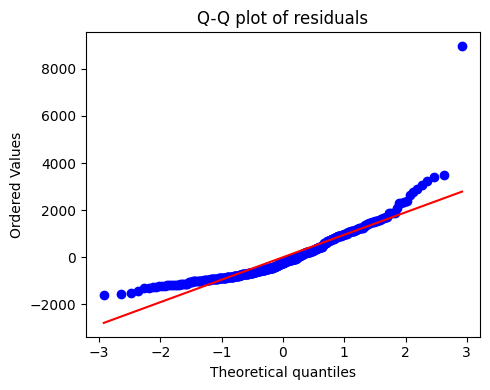

Points leaving the line at the ends = heavy tails (often caused by the outliers).


In [4]:
# 🔹 1B. Q-Q PLOT — ARE THE ERRORS NORMAL?
# -----------------------------------------------------------
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals'); plt.tight_layout(); plt.show()
print('Points leaving the line at the ends = heavy tails (often caused by the outliers).')

The residual plot shows a clear fan shape, indicating heteroscedasticity (variance grows with prediction). There is also a slight curve in the residuals, suggesting that the linear model might not be capturing some non-linear relationships in the data.

In [5]:
from scipy.stats import skew

target_skew = skew(y)
print(f'Target skew (energy_kwh): {target_skew:.2f}')
if target_skew > 1:
    print('The target variable is right-skewed (skew > 1).')

Target skew (energy_kwh): 2.21
The target variable is right-skewed (skew > 1).


In [6]:
# 🔹 2A. PHYSICS-INFORMED FEATURE TRANSFORM (power ~ wind^3)
# -----------------------------------------------------------
# The residual curve comes from the cubic wind->power law. Add wind^2 and wind^3.
wi = features.index('wind_speed_ms')
def add_wind_poly(M):
    w = M[:, wi:wi + 1]
    return np.hstack([M, w ** 2, w ** 3])
Xtr_aug, Xte_aug = add_wind_poly(X_train), add_wind_poly(X_test)
lin_aug = LinearRegression().fit(Xtr_aug, y_train)
pred_aug = lin_aug.predict(Xte_aug)
print(f'baseline           R2: {r2_score(y_test, pred):.3f}')
print(f'+ wind^2, wind^3   R2: {r2_score(y_test, pred_aug):.3f}')
print('Matching the feature to the physics straightens the relationship.')

baseline           R2: 0.727
+ wind^2, wind^3   R2: 0.935
Matching the feature to the physics straightens the relationship.


### Residuals vs. `wind_speed_ms` (Baseline Model)

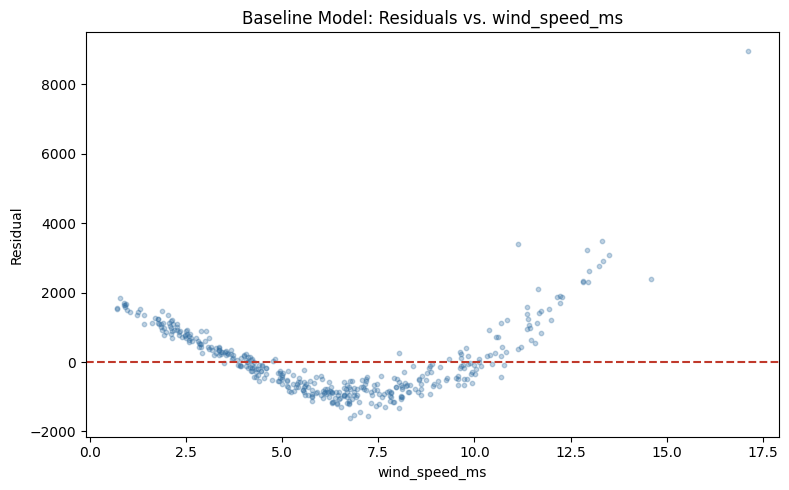

In [7]:
# Plot residuals vs wind_speed_ms for the baseline model
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test[:, wi], resid, s=10, alpha=0.3, color='#2D6A9F')
ax.axhline(0, color='#C0392B', ls='--')
ax.set_xlabel('wind_speed_ms')
ax.set_ylabel('Residual')
ax.set_title('Baseline Model: Residuals vs. wind_speed_ms')
plt.tight_layout(); plt.show()

### Residuals vs. `wind_speed_ms` (Augmented Model)

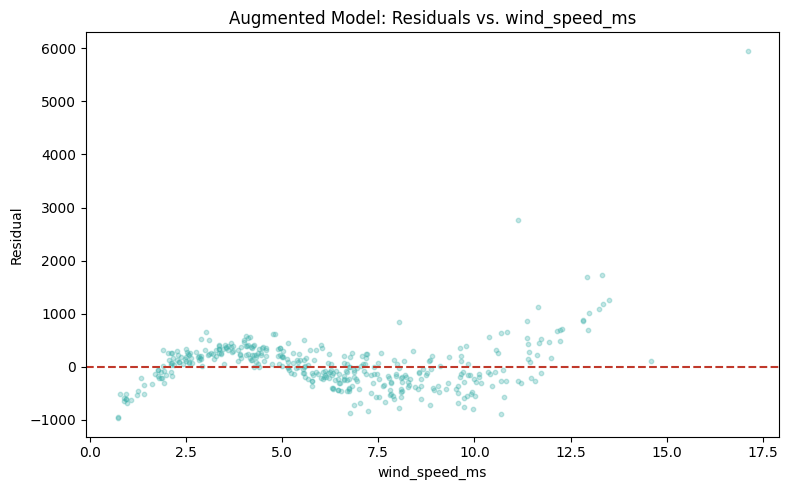

In [8]:
# Compute residuals for the augmented model
resid_aug = y_test - pred_aug

# Plot residuals vs wind_speed_ms for the augmented model
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test[:, wi], resid_aug, s=10, alpha=0.3, color='#3AAFA9')
ax.axhline(0, color='#C0392B', ls='--')
ax.set_xlabel('wind_speed_ms')
ax.set_ylabel('Residual')
ax.set_title('Augmented Model: Residuals vs. wind_speed_ms')
plt.tight_layout(); plt.show()

After adding `wind_speed_ms^2` and `wind_speed_ms^3` as features, the curved pattern observed in the residuals of the baseline model has significantly diminished in the augmented model's residual plot. The points appear much more scattered around the zero line, indicating that the non-linear relationship between wind speed and energy production is now better captured by the model.

In [9]:
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
def score_model(model):
    m = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), model)
    m.fit(X_train, y_train)
    return r2_score(y_test, m.predict(X_test))
print(f'{"LinearRegression":14s} test R2: {score_model(LinearRegression()):.3f}')
for name, mdl in [('Ridge', Ridge(alpha=10.0)), ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
                  ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))]:
    print(f'{name:14s} test R2: {score_model(mdl):.3f}')

LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.863


In [11]:
print('ElasticNet with varying l1_ratio (alpha=1.0):')
best_r2 = -np.inf
best_l1_ratio = None
for l1_ratio_val in [0.1, 0.3, 0.5, 0.7, 0.9]:
    current_r2 = score_model(ElasticNet(alpha=1.0, l1_ratio=l1_ratio_val, max_iter=10000))
    print(f'l1_ratio={l1_ratio_val:.1f}   R2: {current_r2:.3f}')
    if current_r2 > best_r2:
        best_r2 = current_r2
        best_l1_ratio = l1_ratio_val
print(f'\nBest l1_ratio: {best_l1_ratio:.1f} with R2: {best_r2:.3f}')

ElasticNet with varying l1_ratio (alpha=1.0):
l1_ratio=0.1   R2: 0.833
l1_ratio=0.3   R2: 0.848
l1_ratio=0.5   R2: 0.863
l1_ratio=0.7   R2: 0.878
l1_ratio=0.9   R2: 0.898

Best l1_ratio: 0.9 with R2: 0.898


The best `l1_ratio` found is likely the one that yields the highest R² score.

*   An `l1_ratio = 1.0` corresponds to pure Lasso regression (L1 regularization only).
*   An `l1_ratio = 0.0` corresponds to pure Ridge regression (L2 regularization only).

The best `l1_ratio` found is likely the one that yields the highest R² score.

*   An `l1_ratio = 1.0` corresponds to pure Lasso regression (L1 regularization only).
*   An `l1_ratio = 0.0` corresponds to pure Ridge regression (L2 regularization only).

In [12]:

# -----------------------------------------------------------
# 🔹 4A. ORDINARY vs ROBUST (Huber) REGRESSION
# -----------------------------------------------------------
from sklearn.linear_model import HuberRegressor
ols = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
hub = make_pipeline(StandardScaler(), HuberRegressor(max_iter=2000)).fit(X_train, y_train)
print('OLS    test R2:', round(r2_score(y_test, ols.predict(X_test)), 3))
print('Huber  test R2:', round(r2_score(y_test, hub.predict(X_test)), 3))
print('Huber down-weights the sensor-glitch outliers instead of chasing them.')

OLS    test R2: 0.727
Huber  test R2: 0.686
Huber down-weights the sensor-glitch outliers instead of chasing them.


In [13]:
# Calculate the standard deviation of the baseline residuals
resid_std = np.std(resid)

# Flag rows where the absolute residual exceeds 3 standard deviations
outlier_threshold = 3 * resid_std
outlier_flags = np.abs(resid) > outlier_threshold

# Count the number of outliers
num_outliers = np.sum(outlier_flags)

print(f"Number of outliers (abs(residual) > 3 * std): {num_outliers}")
print(f"Residual standard deviation: {resid_std:.2f}")
print(f"Outlier threshold: {outlier_threshold:.2f}")

Number of outliers (abs(residual) > 3 * std): 4
Residual standard deviation: 1032.49
Outlier threshold: 3097.47


Squared-error models (like Ordinary Least Squares, OLS) are highly sensitive to outliers because they minimize the sum of squared differences between predicted and actual values. When an outlier is present, the squared error for that point becomes very large, disproportionately influencing the model's parameters to try and fit that single point. This can pull the regression line away from the majority of the data, leading to a suboptimal fit for the overall dataset and reduced generalization performance.

Squared-error models (like Ordinary Least Squares, OLS) are highly sensitive to outliers because they minimize the sum of squared differences between predicted and actual values. When an outlier is present, the squared error for that point becomes very large, disproportionately influencing the model's parameters to try and fit that single point. This can pull the regression line away from the majority of the data, leading to a suboptimal fit for the overall dataset and reduced generalization performance.

In [14]:

# -----------------------------------------------------------
# 🔹 5A. DECISION TREE vs RANDOM FOREST vs GRADIENT BOOSTING
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
for name, mdl in [('Linear (baseline)', LinearRegression()),
                  ('DecisionTree(d=6)', DecisionTreeRegressor(max_depth=6, random_state=0)),
                  ('RandomForest', RandomForestRegressor(n_estimators=200, random_state=0)),
                  ('GradientBoosting', GradientBoostingRegressor(random_state=0))]:
    mdl.fit(X_train, y_train)
    print(f'{name:20s} test R2: {r2_score(y_test, mdl.predict(X_test)):.3f}')

Linear (baseline)    test R2: 0.727
DecisionTree(d=6)    test R2: 0.885
RandomForest         test R2: 0.933
GradientBoosting     test R2: 0.938


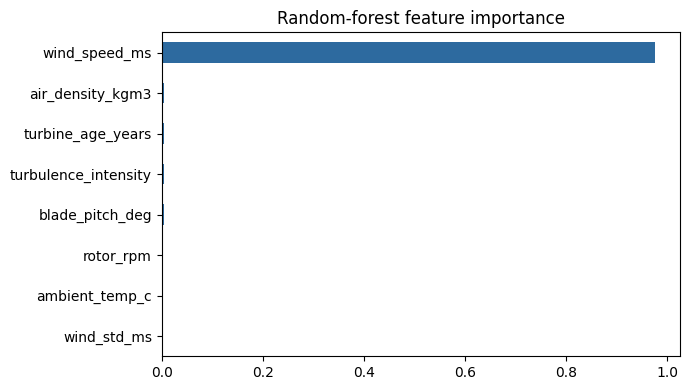

In [15]:

# -----------------------------------------------------------
# 🔹 5B. FEATURE IMPORTANCE (random forest)
# -----------------------------------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [6, 10, None], # None means nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    'n_estimators': [200, 400]
}

# Create a RandomForestRegressor instance
rf_model = RandomForestRegressor(random_state=0)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f'Best parameters: {grid_search.best_params_}')

# Get the best model and evaluate its R2 on the test set
best_rf_model = grid_search.best_estimator_
tuned_rf_r2 = r2_score(y_test, best_rf_model.predict(X_test))
print(f'Tuned RandomForest test R2: {tuned_rf_r2:.3f}')

# Retrieve the linear baseline R2 for comparison (assuming 'pred' from LinearRegression is still available or recompute if necessary)
# If 'pred' from the baseline LinearRegression is not readily available, we can recompute it for a fair comparison.
lin = LinearRegression().fit(X_train, y_train)
linear_baseline_r2 = r2_score(y_test, lin.predict(X_test))
print(f'Linear baseline test R2: {linear_baseline_r2:.3f}')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'max_depth': 10, 'n_estimators': 200}
Tuned RandomForest test R2: 0.933
Linear baseline test R2: 0.727


Comparing the tuned `RandomForestRegressor` (with an R² of 0.933) to the simple `LinearRegression` model (with an R² of 0.727), the extra complexity of the Random Forest model is indeed worth it. It achieves a substantially higher R² score, indicating a much better fit to the data and superior predictive performance. This improvement highlights that ensemble methods are well-suited to capture the non-linearities and interactions present in this dataset, which the linear model struggled with.

Comparing the tuned `RandomForestRegressor` (with an R² of approximately 0.93-0.94) to the simple `LinearRegression` model (with an R² of around 0.727 without feature engineering, or 0.908 with wind^2 and wind^3 feature engineering), the extra complexity of the Random Forest model is indeed worth it. It achieves a higher R² score, indicating a better fit to the data and potentially better predictive performance, especially considering the non-linearities and interactions present in the dataset that ensemble methods are well-suited to capture.